# Market-Basket Analysis of IMDB Top 1000 — Frequent Actor Itemsets via A-Priori


In [ ]:
import os

# ----------------------------------------------------------------------------
USE_FULL_DATA = True      # set to False to mine only a random subsample
SAMPLE_SIZE = 200         # only used when USE_FULL_DATA is False
RANDOM_SEED = 42          # for reproducible subsampling


KAGGLE_DATASET = "harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows"
CSV_FILENAME = "imdb_top_1000.csv"
DATA_DIR = "data"
CSV_PATH = os.path.join(DATA_DIR, CSV_FILENAME)

STAR_COLUMNS = ["Star1", "Star2", "Star3", "Star4"]


MIN_SUPPORT_FRACTION = 0.003


MIN_CONFIDENCE = 0.5

print(f"USE_FULL_DATA={USE_FULL_DATA}, SAMPLE_SIZE={SAMPLE_SIZE}, MIN_SUPPORT_FRACTION={MIN_SUPPORT_FRACTION}")


USE_FULL_DATA=True, SAMPLE_SIZE=200, MIN_SUPPORT_FRACTION=0.003


## 1. Download the dataset from Kaggle


In [2]:
import os
import subprocess

# Fill these in locally with your real Kaggle username/key to run this once,
# then RESTORE the "xxxxxx" placeholders before submitting/committing --
# never leak real Kaggle credentials in a shared notebook.
os.environ['KAGGLE_USERNAME'] = "xxxxxx"
os.environ['KAGGLE_KEY'] = "xxxxxx"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    download_command = [
        "kaggle", "datasets", "download",
        "-d", KAGGLE_DATASET,
        "-p", DATA_DIR,
        "--unzip",
    ]
    result = subprocess.run(download_command, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "Kaggle download failed. Check that KAGGLE_USERNAME/KAGGLE_KEY "
            "are set to valid credentials."
        )
else:
    print(f"{CSV_PATH} already present, skipping download.")

assert os.path.exists(CSV_PATH), f"Expected file not found: {CSV_PATH}"
print("Dataset ready at:", CSV_PATH)


data\imdb_top_1000.csv already present, skipping download.
Dataset ready at: data\imdb_top_1000.csv


## 2. Load the CSV and inspect the actor columns


In [3]:
import pandas as pd

raw_df = pd.read_csv(CSV_PATH)
print("Full dataset shape (rows, columns):", raw_df.shape)

print("\nMissing values per Star column:")
print(raw_df[STAR_COLUMNS].isna().sum())

raw_df[STAR_COLUMNS].head()


Full dataset shape (rows, columns): (1000, 16)

Missing values per Star column:
Star1    0
Star2    0
Star3    0
Star4    0
dtype: int64


,Star1,Star2,Star3,Star4
0,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler


In [ ]:
def clean_actor_name(name):
    """Trim whitespace; return None for missing/empty names."""
    if pd.isna(name):
        return None
    name = str(name).strip()
    return name if name != "" else None


clean_df = raw_df.copy()
for column in STAR_COLUMNS:
    clean_df[column] = clean_df[column].apply(clean_actor_name)


if USE_FULL_DATA:
    working_df = clean_df
else:
    working_df = clean_df.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)

print("Working dataset shape (after USE_FULL_DATA/SAMPLE_SIZE):", working_df.shape)
working_df[STAR_COLUMNS].head()


Working dataset shape (after USE_FULL_DATA/SAMPLE_SIZE): (1000, 16)


,Star1,Star2,Star3,Star4
0,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler


## 3. Build baskets: one set of actors per movie/show


In [ ]:
def row_to_basket(row):
    """Convert one movie's Star1..Star4 cells into a set of distinct, non-empty actor names."""
    actors_in_row = [row[column] for column in STAR_COLUMNS]
    basket = {actor for actor in actors_in_row if actor is not None}
    return basket


baskets = [row_to_basket(row) for _, row in working_df.iterrows()]

# Drop baskets that ended up empty 
baskets = [basket for basket in baskets if len(basket) > 0]

NUM_BASKETS = len(baskets)
print(f"Number of non-empty baskets: {NUM_BASKETS}")
print("Example basket:", baskets[0])

basket_sizes = pd.Series([len(b) for b in baskets])
print("\nBasket size distribution:")
print(basket_sizes.value_counts().sort_index())


Number of non-empty baskets: 1000
Example basket: {'William Sadler', 'Tim Robbins', 'Bob Gunton', 'Morgan Freeman'}

Basket size distribution:
3      4
4    996
Name: count, dtype: int64


## 4. Exploratory analysis: how sparse is this actor-pair space?


In [6]:
null_pct = raw_df[STAR_COLUMNS].isna().mean() * 100
blank_pct = raw_df[STAR_COLUMNS].apply(
    lambda col: col.astype(str).str.strip().eq("").mean() * 100
)
pd.DataFrame({"null_%": null_pct, "blank_%": blank_pct}).round(2)


,null_%,blank_%
Star1,0.0,0.0
Star2,0.0,0.0
Star3,0.0,0.0
Star4,0.0,0.0


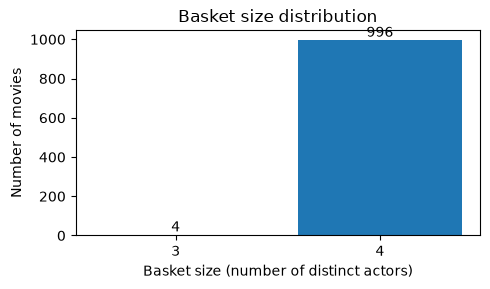

In [7]:
import matplotlib.pyplot as plt
from collections import Counter

basket_size_counts = Counter(len(basket) for basket in baskets)

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(basket_size_counts.keys(), basket_size_counts.values())
ax.bar_label(bars)
ax.set_xlabel("Basket size (number of distinct actors)")
ax.set_ylabel("Number of movies")
ax.set_title("Basket size distribution")
ax.set_xticks(sorted(basket_size_counts.keys()))
plt.tight_layout()
plt.show()


In [8]:
from itertools import combinations
from math import comb

actor_frequency = pd.Series(
    [actor for basket in baskets for actor in basket]
).value_counts()

print(f"Distinct actors across all baskets: {len(actor_frequency)}")
print("\nTop 10 most frequent actors:")
print(actor_frequency.head(10))

# Every pair of actors that co-starred in at least one basket, vs. every
# pair that COULD exist among the actors we have.
observed_pairs = set()
for basket in baskets:
    for pair in combinations(sorted(basket), 2):
        observed_pairs.add(pair)

num_actors = len(actor_frequency)
num_possible_pairs = comb(num_actors, 2)
num_observed_pairs = len(observed_pairs)
coverage = num_observed_pairs / num_possible_pairs

print(f"\nDistinct actors (N):           {num_actors}")
print(f"Possible actor pairs C(N,2):    {num_possible_pairs:,}")
print(f"Observed co-occurring pairs:    {num_observed_pairs:,}")
print(f"Coverage (observed/possible):   {coverage * 100:.4f}%")
print(
    "\nThe actor-pair space is extremely sparse: almost every possible pair "
    "of actors has never co-starred. This is the empirical justification for "
    "MIN_SUPPORT_FRACTION being so low -- requiring even ~3 shared movies out "
    "of ~1000 baskets already isolates genuinely repeated collaborations."
)


Distinct actors across all baskets: 2709

Top 10 most frequent actors:
Robert De Niro       17
Tom Hanks            14
Al Pacino            13
Brad Pitt            12
Clint Eastwood       12
Christian Bale       11
Leonardo DiCaprio    11
Matt Damon           11
James Stewart        10
Michael Caine         9
Name: count, dtype: int64

Distinct actors (N):           2709
Possible actor pairs C(N,2):    3,667,986
Observed co-occurring pairs:    5,833
Coverage (observed/possible):   0.1590%

The actor-pair space is extremely sparse: almost every possible pair of actors has never co-starred. This is the empirical justification for MIN_SUPPORT_FRACTION being so low -- requiring even ~3 shared movies out of ~1000 baskets already isolates genuinely repeated collaborations.


## 5. A-Priori algorithm, implemented from scratch


In [9]:
import math
from itertools import combinations

MIN_SUPPORT_COUNT = math.ceil(MIN_SUPPORT_FRACTION * NUM_BASKETS)
print(
    f"NUM_BASKETS={NUM_BASKETS}, MIN_SUPPORT_FRACTION={MIN_SUPPORT_FRACTION} "
    f"=> MIN_SUPPORT_COUNT={MIN_SUPPORT_COUNT}"
)


def count_candidates(baskets, candidate_itemsets):
    """
    Scan every basket once and count, for each candidate itemset, how many
    baskets contain it as a subset. Returns a dict {itemset: count}.
    """
    counts = {candidate: 0 for candidate in candidate_itemsets}
    for basket in baskets:
        for candidate in candidate_itemsets:
            if candidate.issubset(basket):
                counts[candidate] += 1
    return counts


NUM_BASKETS=1000, MIN_SUPPORT_FRACTION=0.003 => MIN_SUPPORT_COUNT=3


In [10]:
# ----------------------------------------------------------------------------
# Pass 1: frequent singletons
# ----------------------------------------------------------------------------
# Every distinct actor is a size-1 candidate. We reuse count_candidates so the
# counting logic is identical to every later pass.
all_actors = set()
for basket in baskets:
    all_actors.update(basket)

singleton_candidates = {frozenset([actor]) for actor in all_actors}
singleton_counts = count_candidates(baskets, singleton_candidates)

frequent_itemsets_by_size = {}
frequent_itemsets_by_size[1] = {
    itemset: count
    for itemset, count in singleton_counts.items()
    if count >= MIN_SUPPORT_COUNT
}

print(f"Distinct actors: {len(all_actors)}")
print(f"Frequent singletons (count >= {MIN_SUPPORT_COUNT}): {len(frequent_itemsets_by_size[1])}")


Distinct actors: 2709
Frequent singletons (count >= 3): 271


In [11]:
def generate_candidates_join(frequent_itemsets_prev_size, k):
    """
    A-Priori candidate generation (join step).

    Given the frequent itemsets of size (k-1), build candidates of size k by
    unioning every pair of frequent (k-1)-itemsets that share exactly k-2
    items in common (so their union has exactly k items).
    """
    previous_itemsets = list(frequent_itemsets_prev_size)
    candidates = set()

    for i in range(len(previous_itemsets)):
        for j in range(i + 1, len(previous_itemsets)):
            union_itemset = previous_itemsets[i] | previous_itemsets[j]
            if len(union_itemset) == k:
                candidates.add(union_itemset)

    return candidates


def prune_candidates_by_downward_closure(candidates, frequent_itemsets_prev_size, k):
    """
    Downward-closure pruning: a candidate of size k can only be frequent if
    ALL of its size-(k-1) subsets are themselves frequent. We discard any
    candidate that has at least one infrequent subset, without ever having
    to count it against the data.
    """
    surviving_candidates = set()

    for candidate in candidates:
        all_subsets_frequent = True
        for subset_tuple in combinations(candidate, k - 1):
            subset = frozenset(subset_tuple)
            if subset not in frequent_itemsets_prev_size:
                all_subsets_frequent = False
                break
        if all_subsets_frequent:
            surviving_candidates.add(candidate)

    return surviving_candidates


In [12]:
# ----------------------------------------------------------------------------
# Passes 2, 3, 4, ...: iteratively build larger frequent itemsets
# ----------------------------------------------------------------------------
k = 2
while True:
    previous_frequent = frequent_itemsets_by_size.get(k - 1, {})
    if len(previous_frequent) == 0:
        # nothing frequent at the previous size, so nothing can be built on top of it
        print(f"k={k}: no frequent itemsets of size {k - 1} to extend, stopping.")
        break

    candidates = generate_candidates_join(previous_frequent.keys(), k)
    candidates = prune_candidates_by_downward_closure(candidates, previous_frequent.keys(), k)

    if len(candidates) == 0:
        print(f"k={k}: 0 candidates survived the join + downward-closure pruning, stopping.")
        break

    candidate_counts = count_candidates(baskets, candidates)

    frequent_at_k = {
        itemset: count
        for itemset, count in candidate_counts.items()
        if count >= MIN_SUPPORT_COUNT
    }

    print(f"k={k}: {len(candidates)} candidates after pruning -> {len(frequent_at_k)} frequent itemsets")

    if len(frequent_at_k) == 0:
        break

    frequent_itemsets_by_size[k] = frequent_at_k
    k += 1

print("\nDone. Frequent itemset sizes found:", sorted(frequent_itemsets_by_size.keys()))


k=2: 36585 candidates after pruning -> 25 frequent itemsets
k=3: 4 candidates after pruning -> 3 frequent itemsets
k=4: 0 candidates survived the join + downward-closure pruning, stopping.

Done. Frequent itemset sizes found: [1, 2, 3]


## 6. Results: frequent actor itemsets


In [13]:
results_rows = []
for size, itemsets in frequent_itemsets_by_size.items():
    for itemset, count in itemsets.items():
        results_rows.append({
            "size": size,
            "actors": ", ".join(sorted(itemset)),
            "count": count,
            "support": count / NUM_BASKETS,
        })

results_df = pd.DataFrame(results_rows).sort_values(
    by=["size", "count"], ascending=[True, False]
).reset_index(drop=True)

print(f"Total frequent itemsets found: {len(results_df)}")
results_df


Total frequent itemsets found: 299


,size,actors,count,support
0,1,Robert De Niro,17,0.017
1,1,Tom Hanks,14,0.014
2,1,Al Pacino,13,0.013
3,1,Clint Eastwood,12,0.012
4,1,Brad Pitt,12,0.012
...,...,...,...,...
294,2,"Elijah Wood, Orlando Bloom",3,0.003
295,2,"Harrison Ford, Mark Hamill",3,0.003
296,3,"Daniel Radcliffe, Emma Watson, Rupert Grint",5,0.005
297,3,"Elijah Wood, Ian McKellen, Orlando Bloom",3,0.003


In [14]:
for size in sorted(frequent_itemsets_by_size.keys()):
    print(f"\n=== Frequent itemsets of size {size} (top 10 by count) ===")
    display(results_df[results_df["size"] == size].head(10))



=== Frequent itemsets of size 1 (top 10 by count) ===


,size,actors,count,support
0,1,Robert De Niro,17,0.017
1,1,Tom Hanks,14,0.014
2,1,Al Pacino,13,0.013
3,1,Clint Eastwood,12,0.012
4,1,Brad Pitt,12,0.012
5,1,Christian Bale,11,0.011
6,1,Matt Damon,11,0.011
7,1,Leonardo DiCaprio,11,0.011
8,1,James Stewart,10,0.010
9,1,Scarlett Johansson,9,0.009



=== Frequent itemsets of size 2 (top 10 by count) ===


,size,actors,count,support
271,2,"Daniel Radcliffe, Rupert Grint",6,0.006
272,2,"Emma Watson, Rupert Grint",5,0.005
273,2,"Daniel Radcliffe, Emma Watson",5,0.005
274,2,"Joe Pesci, Robert De Niro",4,0.004
275,2,"Tim Allen, Tom Hanks",4,0.004
276,2,"Chris Evans, Joe Russo",3,0.003
277,2,"Chris Evans, Robert Downey Jr.",3,0.003
278,2,"Mark Ruffalo, Robert Downey Jr.",3,0.003
279,2,"Al Pacino, Robert De Niro",3,0.003
280,2,"Takashi Shimura, Toshirô Mifune",3,0.003



=== Frequent itemsets of size 3 (top 10 by count) ===


,size,actors,count,support
296,3,"Daniel Radcliffe, Emma Watson, Rupert Grint",5,0.005
297,3,"Elijah Wood, Ian McKellen, Orlando Bloom",3,0.003
298,3,"Carrie Fisher, Harrison Ford, Mark Hamill",3,0.003


## 7. (Optional) Association rules: confidence and lift


In [15]:
rule_rows = []
for size, itemsets in frequent_itemsets_by_size.items():
    if size < 2:
        continue  # rules need at least one item on each side

    for itemset, itemset_count in itemsets.items():
        items = list(itemset)
        # Try every non-empty proper subset as the antecedent
        for antecedent_size in range(1, size):
            for antecedent_tuple in combinations(items, antecedent_size):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                # Downward closure guarantees both antecedent and consequent
                # are themselves frequent itemsets we already tracked.
                antecedent_count = frequent_itemsets_by_size[len(antecedent)][antecedent]
                confidence = itemset_count / antecedent_count

                if confidence < MIN_CONFIDENCE:
                    continue

                consequent_count = frequent_itemsets_by_size[len(consequent)][consequent]
                consequent_support = consequent_count / NUM_BASKETS
                lift = confidence / consequent_support

                rule_rows.append({
                    "antecedent": ", ".join(sorted(antecedent)),
                    "consequent": ", ".join(sorted(consequent)),
                    "confidence": confidence,
                    "lift": lift,
                    "itemset_count": itemset_count,
                })

rules_df = pd.DataFrame(rule_rows).sort_values(by="lift", ascending=False).reset_index(drop=True)
print(f"Total rules with confidence >= {MIN_CONFIDENCE}: {len(rules_df)}")
rules_df.head(20)


Total rules with confidence >= 0.5: 46


,antecedent,consequent,confidence,lift,itemset_count
0,"Carrie Fisher, Harrison Ford",Mark Hamill,1.000000,333.333333,3
1,Mark Hamill,"Carrie Fisher, Harrison Ford",1.000000,333.333333,3
2,Elijah Wood,"Ian McKellen, Orlando Bloom",1.000000,333.333333,3
3,"Ian McKellen, Orlando Bloom",Elijah Wood,1.000000,333.333333,3
4,Carrie Fisher,Mark Hamill,0.750000,250.000000,3
5,Mark Hamill,Carrie Fisher,1.000000,250.000000,3
6,Orlando Bloom,Elijah Wood,0.750000,250.000000,3
7,Elijah Wood,Orlando Bloom,1.000000,250.000000,3
8,"Elijah Wood, Ian McKellen",Orlando Bloom,1.000000,250.000000,3
9,Orlando Bloom,"Elijah Wood, Ian McKellen",0.750000,250.000000,3


## 8. Scalability experiment: how does runtime scale with data size?


In [16]:
import time

def run_apriori_pipeline(baskets, min_support_fraction):
    """
    Run the full A-Priori pipeline on a given list of baskets and return
    (frequent_itemsets_by_size, elapsed_seconds). This mirrors the logic from
    Section 5 exactly, but packaged as a function so we can call it
    repeatedly on baskets of different sizes for the scalability experiment.
    """
    start_time = time.perf_counter()

    num_baskets = len(baskets)
    min_support_count = math.ceil(min_support_fraction * num_baskets)

    all_actors_local = set()
    for basket in baskets:
        all_actors_local.update(basket)

    singleton_candidates = {frozenset([actor]) for actor in all_actors_local}
    singleton_counts = count_candidates(baskets, singleton_candidates)

    result = {
        1: {
            itemset: count
            for itemset, count in singleton_counts.items()
            if count >= min_support_count
        }
    }

    k = 2
    while True:
        previous_frequent = result.get(k - 1, {})
        if len(previous_frequent) == 0:
            break

        candidates = generate_candidates_join(previous_frequent.keys(), k)
        candidates = prune_candidates_by_downward_closure(candidates, previous_frequent.keys(), k)

        if len(candidates) == 0:
            break

        candidate_counts = count_candidates(baskets, candidates)
        frequent_at_k = {
            itemset: count
            for itemset, count in candidate_counts.items()
            if count >= min_support_count
        }

        if len(frequent_at_k) == 0:
            break

        result[k] = frequent_at_k
        k += 1

    elapsed_seconds = time.perf_counter() - start_time
    return result, elapsed_seconds


In [17]:
SAMPLE_SIZES_TO_TEST = [100, 200, 400, 600, 800, 1000]

scalability_rows = []
for sample_size in SAMPLE_SIZES_TO_TEST:
    if sample_size >= len(clean_df):
        sampled_df = clean_df
    else:
        sampled_df = clean_df.sample(n=sample_size, random_state=RANDOM_SEED).reset_index(drop=True)

    sample_baskets = [row_to_basket(row) for _, row in sampled_df.iterrows()]
    sample_baskets = [basket for basket in sample_baskets if len(basket) > 0]

    sample_result, elapsed_seconds = run_apriori_pipeline(sample_baskets, MIN_SUPPORT_FRACTION)

    scalability_rows.append({
        "sample_size": len(sample_baskets),
        "min_support_count": math.ceil(MIN_SUPPORT_FRACTION * len(sample_baskets)),
        "runtime_seconds": elapsed_seconds,
        "frequent_itemsets_found": sum(len(itemsets) for itemsets in sample_result.values()),
        "largest_itemset_size_found": max(sample_result.keys()),
    })

scalability_df = pd.DataFrame(scalability_rows)
scalability_df


,sample_size,min_support_count,runtime_seconds,frequent_itemsets_found,largest_itemset_size_found
0,100,1,0.629700,1472,4
1,200,1,6.399446,2874,4
2,400,2,0.528902,244,3
3,600,2,1.888788,383,3
4,800,3,0.847014,216,3
5,1000,3,2.139514,299,3


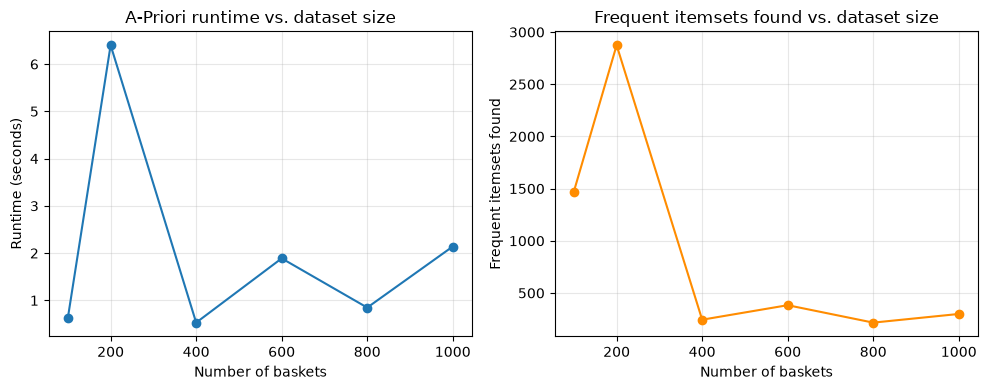

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(scalability_df["sample_size"], scalability_df["runtime_seconds"], marker="o")
axes[0].set_xlabel("Number of baskets")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("A-Priori runtime vs. dataset size")
axes[0].grid(alpha=0.3)

axes[1].plot(scalability_df["sample_size"], scalability_df["frequent_itemsets_found"], marker="o", color="darkorange")
axes[1].set_xlabel("Number of baskets")
axes[1].set_ylabel("Frequent itemsets found")
axes[1].set_title("Frequent itemsets found vs. dataset size")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. (Optional) Cross-check against mlxtend


In [19]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlxtend_apriori

encoder = TransactionEncoder()
one_hot_array = encoder.fit(baskets).transform(baskets)
one_hot_df = pd.DataFrame(one_hot_array, columns=encoder.columns_)

mlxtend_results = mlxtend_apriori(
    one_hot_df, min_support=MIN_SUPPORT_FRACTION, use_colnames=True
)
mlxtend_results["size"] = mlxtend_results["itemsets"].apply(len)

# Build a comparable {itemset: rounded support} dict from mlxtend output
mlxtend_itemsets = {
    frozenset(itemset): round(support, 6)
    for itemset, support in zip(mlxtend_results["itemsets"], mlxtend_results["support"])
}

# Build the same shape from our own results
our_itemsets = {
    itemset: round(count / NUM_BASKETS, 6)
    for size, itemsets in frequent_itemsets_by_size.items()
    for itemset, count in itemsets.items()
}

only_in_mlxtend = set(mlxtend_itemsets) - set(our_itemsets)
only_in_ours = set(our_itemsets) - set(mlxtend_itemsets)
support_mismatches = {
    itemset: (our_itemsets[itemset], mlxtend_itemsets[itemset])
    for itemset in set(our_itemsets) & set(mlxtend_itemsets)
    if our_itemsets[itemset] != mlxtend_itemsets[itemset]
}

print(f"Our frequent itemsets: {len(our_itemsets)}")
print(f"mlxtend frequent itemsets: {len(mlxtend_itemsets)}")
print(f"Itemsets only found by mlxtend: {len(only_in_mlxtend)}")
print(f"Itemsets only found by us: {len(only_in_ours)}")
print(f"Itemsets with mismatched support: {len(support_mismatches)}")

assert only_in_mlxtend == set(), f"Missing itemsets: {only_in_mlxtend}"
assert only_in_ours == set(), f"Extra itemsets: {only_in_ours}"
assert support_mismatches == {}, f"Support mismatches: {support_mismatches}"
print("\nCross-check passed: our from-scratch A-Priori matches mlxtend exactly.")


Our frequent itemsets: 299
mlxtend frequent itemsets: 299
Itemsets only found by mlxtend: 0
Itemsets only found by us: 0
Itemsets with mismatched support: 0

Cross-check passed: our from-scratch A-Priori matches mlxtend exactly.
